In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
from scipy.spatial import cKDTree
import pygtc


In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
class Bolshoi_HaloCatalogue:

    def __init__(self,filepath,
        npart_thresh=100,
        xoff_thresh=0.07,
        spin_thresh=0.07,
        isolation_factor=3):
 
        self.filepath         = filepath
        self.npart_thresh     = npart_thresh
        self.mass_thresh      = npart_thresh * (1.5e8)           # Msun — for reference
        self.log_mass_thresh  = np.log10(npart_thresh * (1.5e8)) # log10 Msun — for comparisons
        self.xoff_thresh      = xoff_thresh
        self.spin_thresh      = spin_thresh
        self.isolation_factor = isolation_factor

        self._load()
        self._relaxation_cut()
        self._isolation_cut()
        self._print_counts()

    # ------------------------------------------------------------------ #
    # Private methods                                                      #
    # ------------------------------------------------------------------ #

    def _load(self):

        COLS = [
            "host_id", "logMh", "ch", "a_50h",
            "Xoff_h", "Spin_h", "Spin_Bullock_h", "ch_K",
            "x_h", "y_h", "z_h", "R_vir",
            "id", "log10Mvir", "Rvir", "rs", "vrms", "scale_of_last_MM",
            "vmax", "x", "y", "z", "vx", "vy", "vz",
            "Jx", "Jy", "Jz", "Spin", "Tidal_Force", "Tidal_ID",
            "Mmvir_all", "M200b", "M200c", "M500c",
            "Xoff", "Voff", "Spin_Bullock",
            "b_to_a", "c_to_a",
            "Ax", "Ay", "Az", "T_by_U",
            "M_pe_Behroozi", "M_pe_Diemer",
            "Macc", "Mpeak", "Vacc", "Vpeak", "Halfmass_Scale",
            "Acc_Rate_Inst", "Acc_Rate_100Myr", "Acc_Rate_1Tdyn",
            "Acc_Rate_2Tdyn", "Acc_Rate_Mpeak",
            "Mpeak_Scale", "Acc_Scale", "First_Acc_Scale",
            "First_Acc_Mvir", "First_Acc_Vmax", "Vmax_at_Mpeak",
            "Tidal_Force_Tdyn"
        ]

        raw        = np.loadtxt(self.filepath)
        self._df   = pd.DataFrame(raw, columns=COLS)

    def _relaxation_cut(self):
        host_props = (
            self._df
            .groupby("host_id")[["Xoff_h", "Spin_h", "R_vir"]]
            .mean()
            .reset_index()
        )
        relaxed_ids = host_props[
            (host_props["Xoff_h"] / host_props["R_vir"] <= self.xoff_thresh) &
            (host_props["Spin_h"] <= self.spin_thresh)
        ]["host_id"].values

        self._df_relaxed = self._df[self._df["host_id"].isin(relaxed_ids)]

    def _isolation_cut(self):
        host_relaxed = (
            self._df_relaxed
            .groupby("host_id")[["x_h", "y_h", "z_h", "R_vir", "logMh"]]
            .mean()
            .reset_index()
        )

        coords   = host_relaxed[["x_h", "y_h", "z_h"]].values
        masses   = host_relaxed["logMh"].values
        r_virial = host_relaxed["R_vir"].values / 1000.0   # kpc/h -> Mpc/h

        tree     = cKDTree(coords)
        isolated = np.ones(len(host_relaxed), dtype=bool)

        for i in range(len(host_relaxed)):
            search_r   = self.isolation_factor * r_virial[i]
            neighbours = tree.query_ball_point(coords[i], r=search_r)
            for j in neighbours:
                if j == i:
                    continue
                if masses[j] >= masses[i]:
                    isolated[i] = False
                    break

        isolated_ids  = host_relaxed[isolated]["host_id"].values
        self._df_isolated  = self._df_relaxed[self._df_relaxed["host_id"].isin(isolated_ids)]

    def _print_counts(self):
        n_raw     = self._df["host_id"].unique().shape[0]
        n_relaxed = self._df_relaxed["host_id"].unique().shape[0]
        n_final   = self._df_isolated["host_id"].unique().shape[0]
        print(
            f"Hosts: total={n_raw}  "
            f"after relaxation={n_relaxed} ({100*n_relaxed/n_raw:.1f}%)  "
            f"after isolation={n_final} ({100*n_final/n_raw:.1f}%)"
        )

    def _build_host_table(self, sample):

        if sample == "isolated":
            host_id_unique = np.sort(self._df_isolated["host_id"].unique())
            groups = self._df_isolated.groupby("host_id")

        if sample == "relaxed":
            host_id_unique = np.sort(self._df_relaxed["host_id"].unique())
            groups = self._df_relaxed.groupby("host_id")

        if sample == "all":
            host_id_unique = np.sort(self._df["host_id"].unique())
            groups = self._df.groupby("host_id")

        logMvir  = np.zeros(len(host_id_unique))
        log1pz50 = np.zeros(len(host_id_unique))
        logc     = np.zeros(len(host_id_unique))
        logNsub  = np.zeros(len(host_id_unique))
        logfsub  = np.zeros(len(host_id_unique))

        for i, hid in enumerate(host_id_unique):
            subset  = groups.get_group(hid)
            subset1 = subset[subset["log10Mvir"] >= self.log_mass_thresh]

            logMh_i  = subset["logMh"].mean()
            c_h_i    = subset["ch"].mean()
            a_half_i = subset["a_50h"].mean()

            z50            = (1.0 / a_half_i) - 1.0
            Nsub_i         = len(subset1)
            host_mass      = 10**logMh_i
            sub_mass_total = np.sum(10**subset1["log10Mvir"])
            f_sub_i        = sub_mass_total / host_mass

            logMvir[i]  = logMh_i
            log1pz50[i] = np.log10(1.0 + z50)
            logc[i]     = np.log10(c_h_i)
            logNsub[i]  = np.log10(Nsub_i)  if Nsub_i > 0  else np.nan
            logfsub[i]  = np.log10(f_sub_i) if f_sub_i > 0 else np.nan

        host_table = pd.DataFrame({
            "logMvir":  logMvir,
            "log1pz50": log1pz50,
            "logc":     logc,
            "logNsub":  logNsub,
            "logfsub":  logfsub,
        })

        return host_table

In [ ]:
# ---- usage ----------------------------------------------------------- #
cat = Bolshoi_HaloCatalogue(
    "../../../misc/ForSebastian/N_AB_sub_BolPlanck.dat",
    npart_thresh=500,
    xoff_thresh=0.07,
    spin_thresh=0.07,
    isolation_factor=5)

Hosts: total=95737  after relaxation=72110 (75.3%)  after isolation=68780 (71.8%)


In [57]:
# all_df = cat._build_host_table(sample="all")
# relaxed_df = cat._build_host_table(sample="relaxed")
isolated_df = cat._build_host_table(sample="isolated")

(0.0, 0.7)

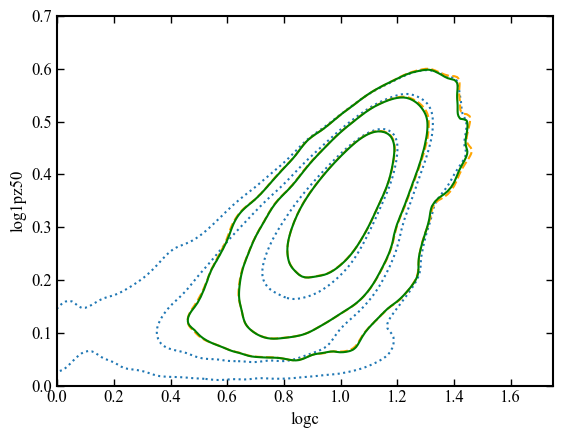

In [58]:
sns.kdeplot(x=all_df["logc"], y=all_df["log1pz50"], levels=levelz, color="C0", linestyles=":", bw_adjust=1.5)
sns.kdeplot(x=relaxed_df["logc"], y=relaxed_df["log1pz50"], levels=levelz, color="orange", linestyles="--", bw_adjust=1.5)
sns.kdeplot(x=isolated_df["logc"], y=isolated_df["log1pz50"], levels=levelz, color="green", linestyles="-", bw_adjust=1.5)
plt.xlim(0, 1.75)
plt.ylim(0, 0.7)

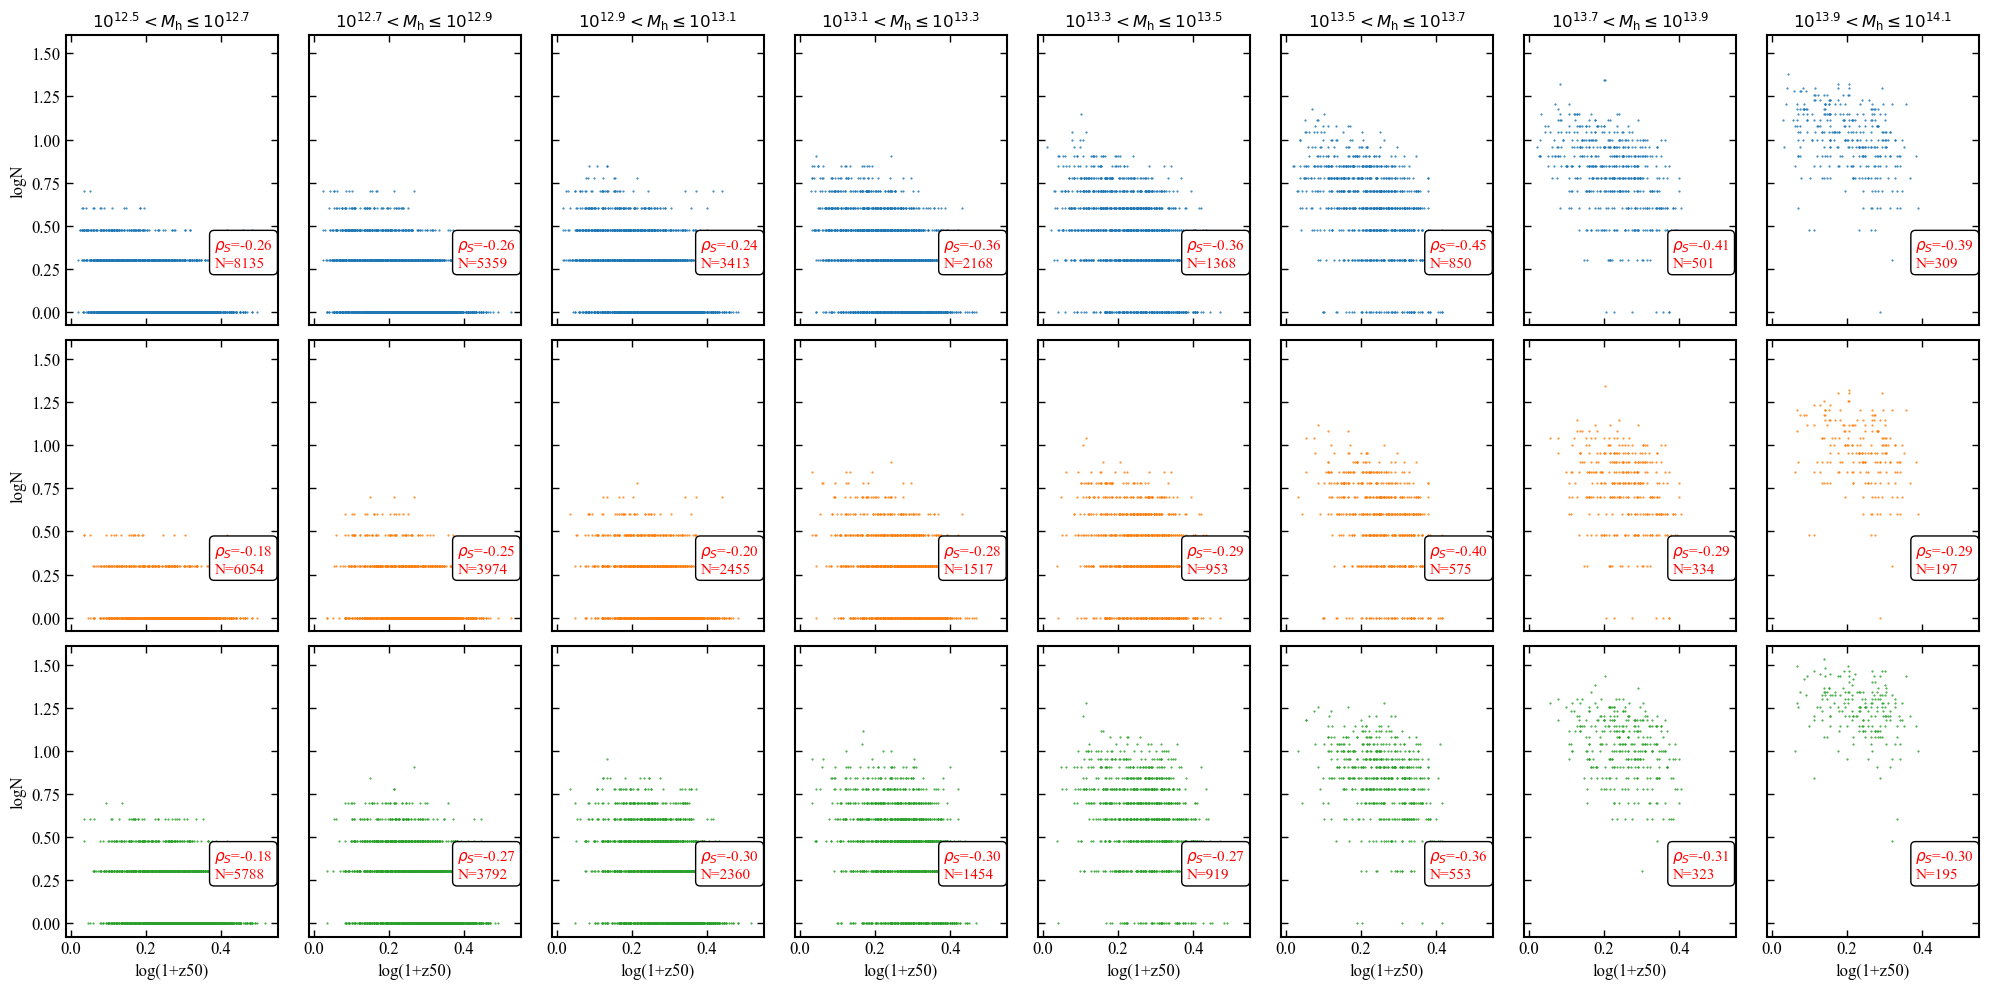

In [59]:
rho_mat = jsm_stats.make_binned_plot([all_df, relaxed_df, isolated_df], xkey="log1pz50", ykey="logNsub", xlabel="log(1+z50)", ylabel="logN")

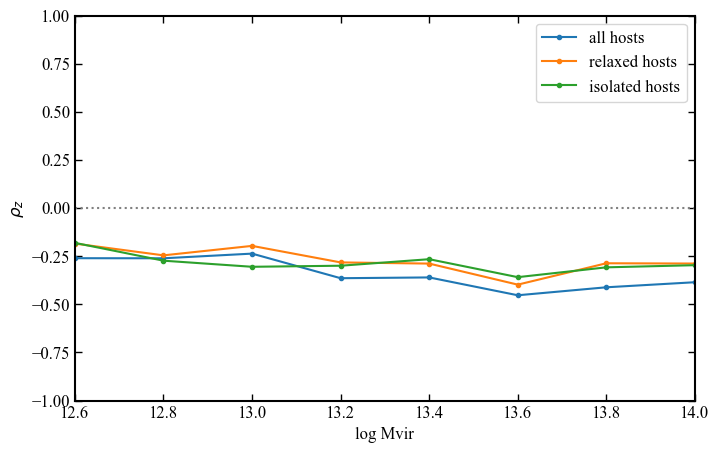

In [60]:
jsm_stats.make_summary_rho(rho_mat, ["all hosts", "relaxed hosts", "isolated hosts"], xlabel="log Mvir", ylabel="$\\rho_z$")

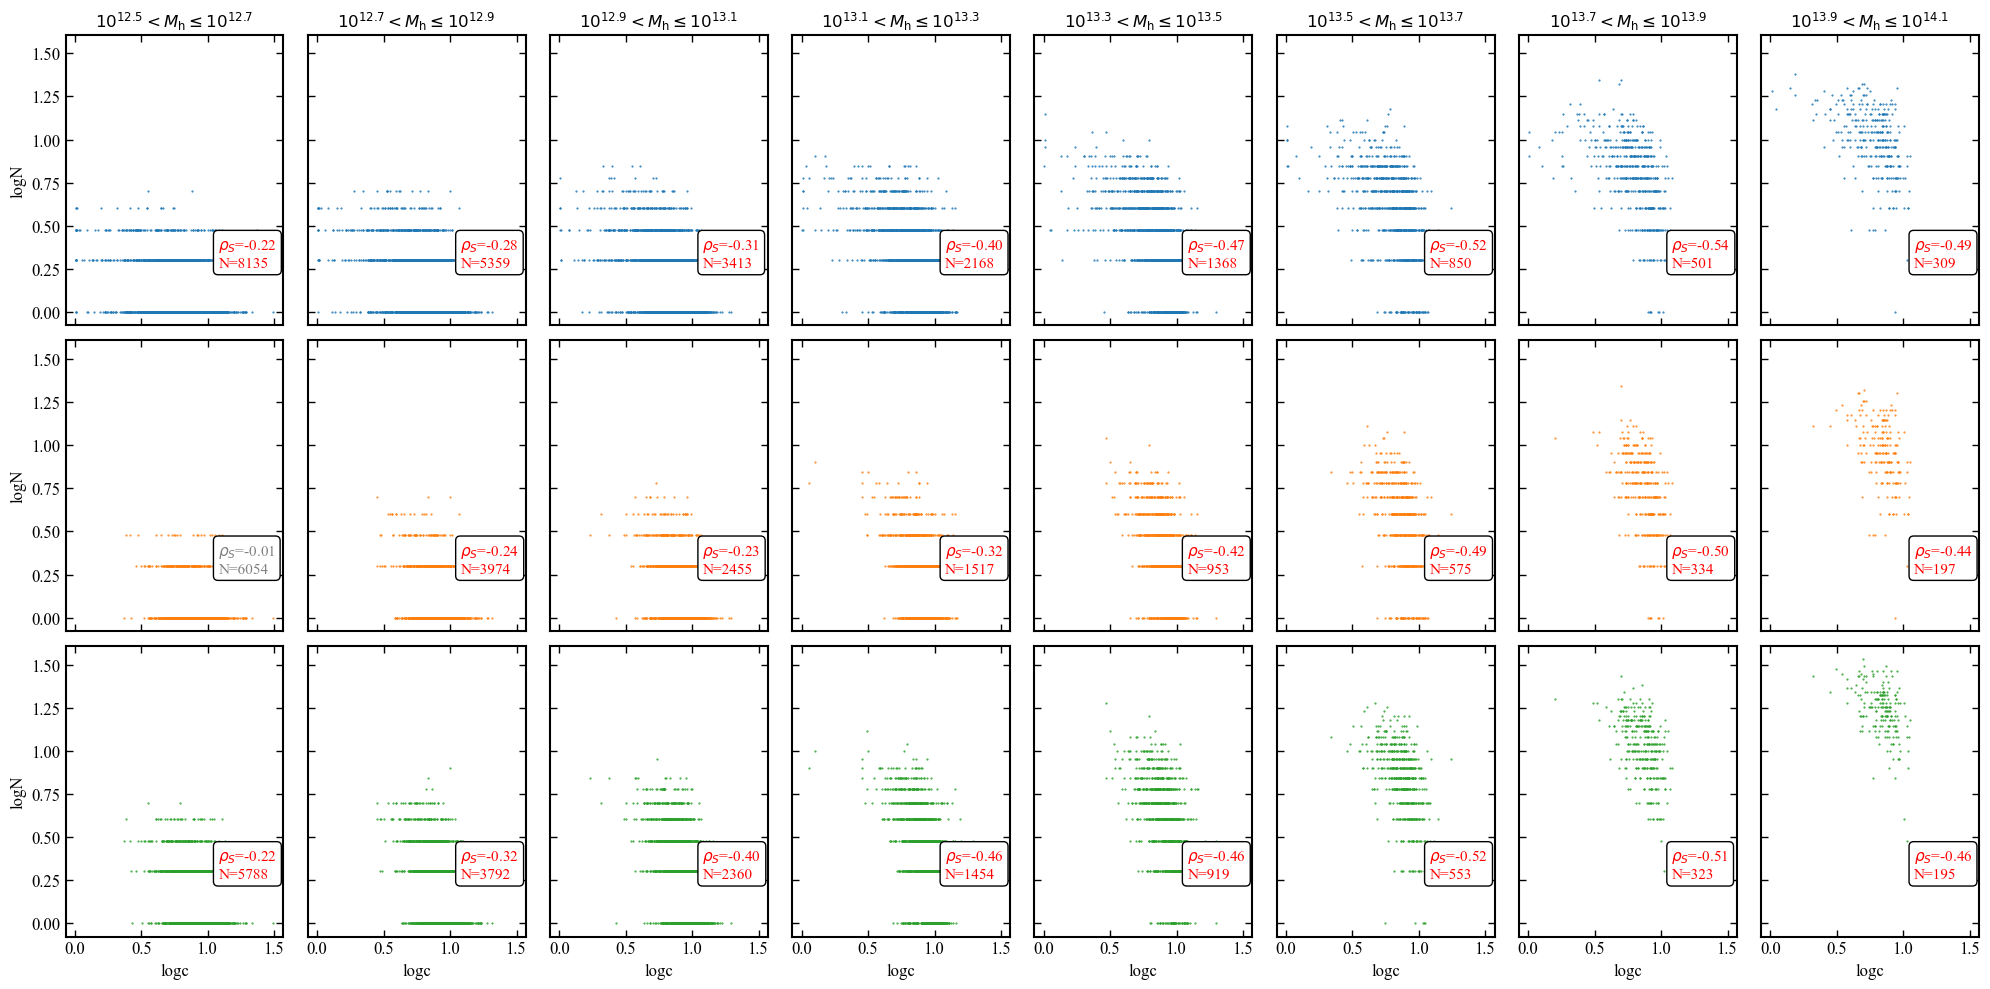

In [61]:
rho_mat = jsm_stats.make_binned_plot([all_df, relaxed_df, isolated_df], xkey="logc", ykey="logNsub", xlabel="logc", ylabel="logN")

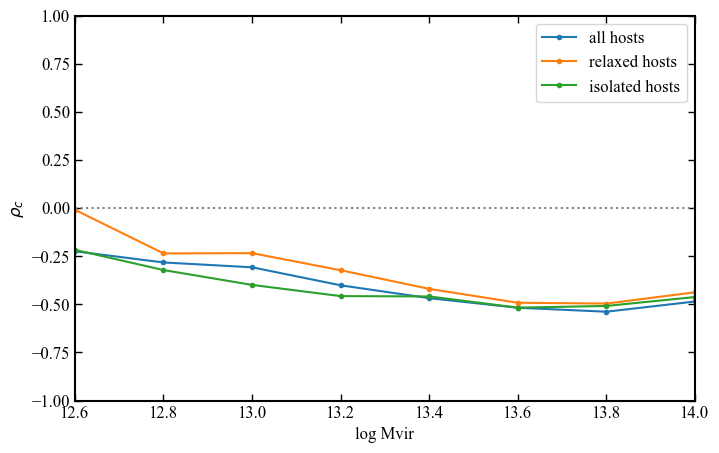

In [62]:
jsm_stats.make_summary_rho(rho_mat, ["all hosts", "relaxed hosts", "isolated hosts"], xlabel="log Mvir", ylabel="$\\rho_c$")